In [92]:
import pandas as pd
# Load master dataset
master = pd.read_csv("/Users/leoss/Documents/GitHub/Capstone/MASTER/Master.csv")
master = master.drop(columns=['Unnamed: 0'], errors='ignore')

c1995 = pd.read_csv('/Users/leoss/Documents/GitHub/Capstone/MASTER/clusters1995.csv')
c1995 = c1995.drop(columns=['Unnamed: 0'], errors='ignore')

c2019 = pd.read_csv('/Users/leoss/Documents/GitHub/Capstone/MASTER/clusters2019.csv')
c2019 = c2019.drop(columns=['Unnamed: 0'], errors='ignore')

clusters_agg = pd.read_csv('/Users/leoss/Documents/GitHub/Capstone/MASTER/clustersagg.csv')
clusters_agg = clusters_agg.drop(columns=['Unnamed: 0'], errors='ignore')

clusters_1995 = pd.read_csv('/Users/leoss/Documents/GitHub/Capstone/MASTER/clusters1995.csv')
clusters_1995 = clusters_1995.drop(columns=['Unnamed: 0'], errors='ignore')

clusters_2019 = pd.read_csv('/Users/leoss/Documents/GitHub/Capstone/MASTER/clusters2019.csv')
clusters_2019 = clusters_2019.drop(columns=['Unnamed: 0'], errors='ignore')

clusters_agg = pd.read_csv('/Users/leoss/Documents/GitHub/Capstone/MASTER/clustersagg.csv')
clusters_agg = clusters_agg.drop(columns=['Unnamed: 0'], errors='ignore')

# Keeping the 95-19 pcas

Master: 3150 obs, 126 countries
Using STATIC PCA: PC1_1995, PC2_1995, PC1_2019, PC2_2019, PCA_Distance
Total features: 25 (17 base + 5 PCA + 1 group + 2 interactions)
All models trained
Importance collected from all models


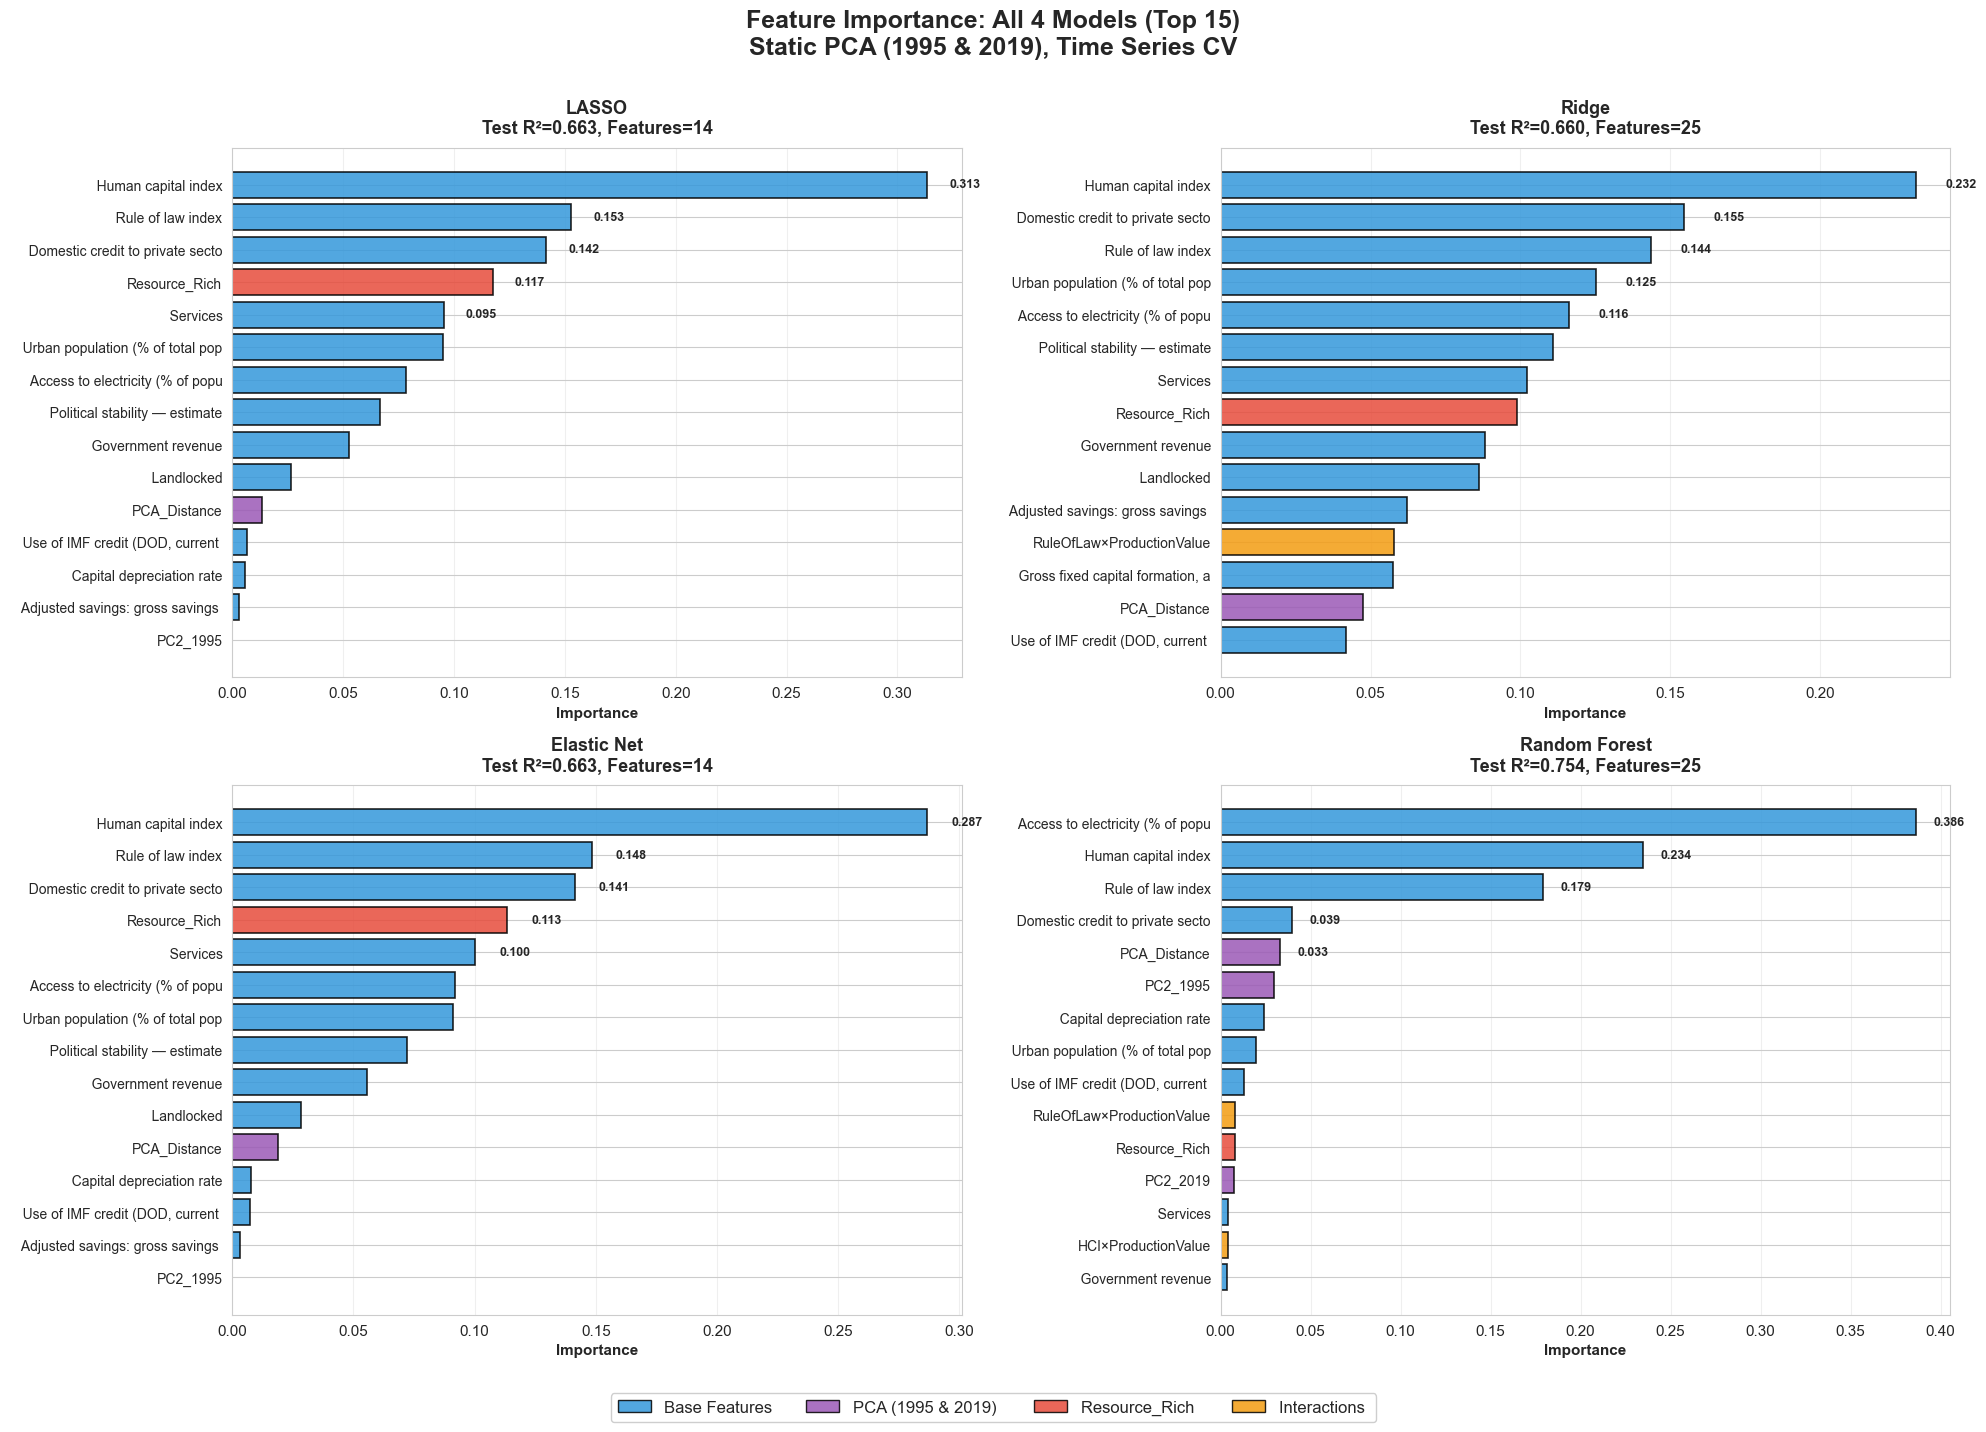


[2/6] Heatmap (top 20 features)...


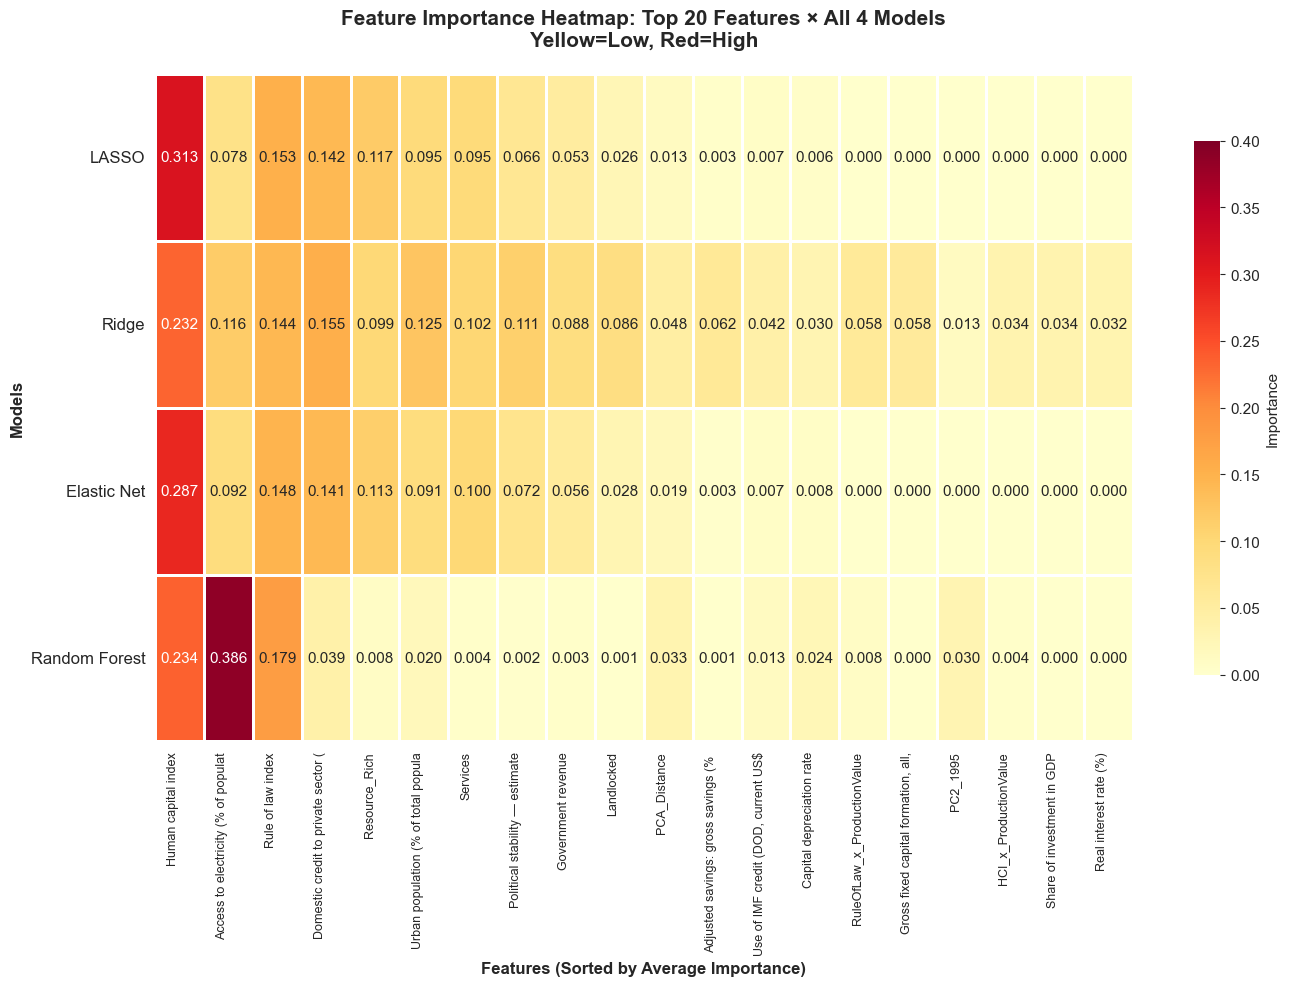


[3/6] Grouped bar chart (top 10)...


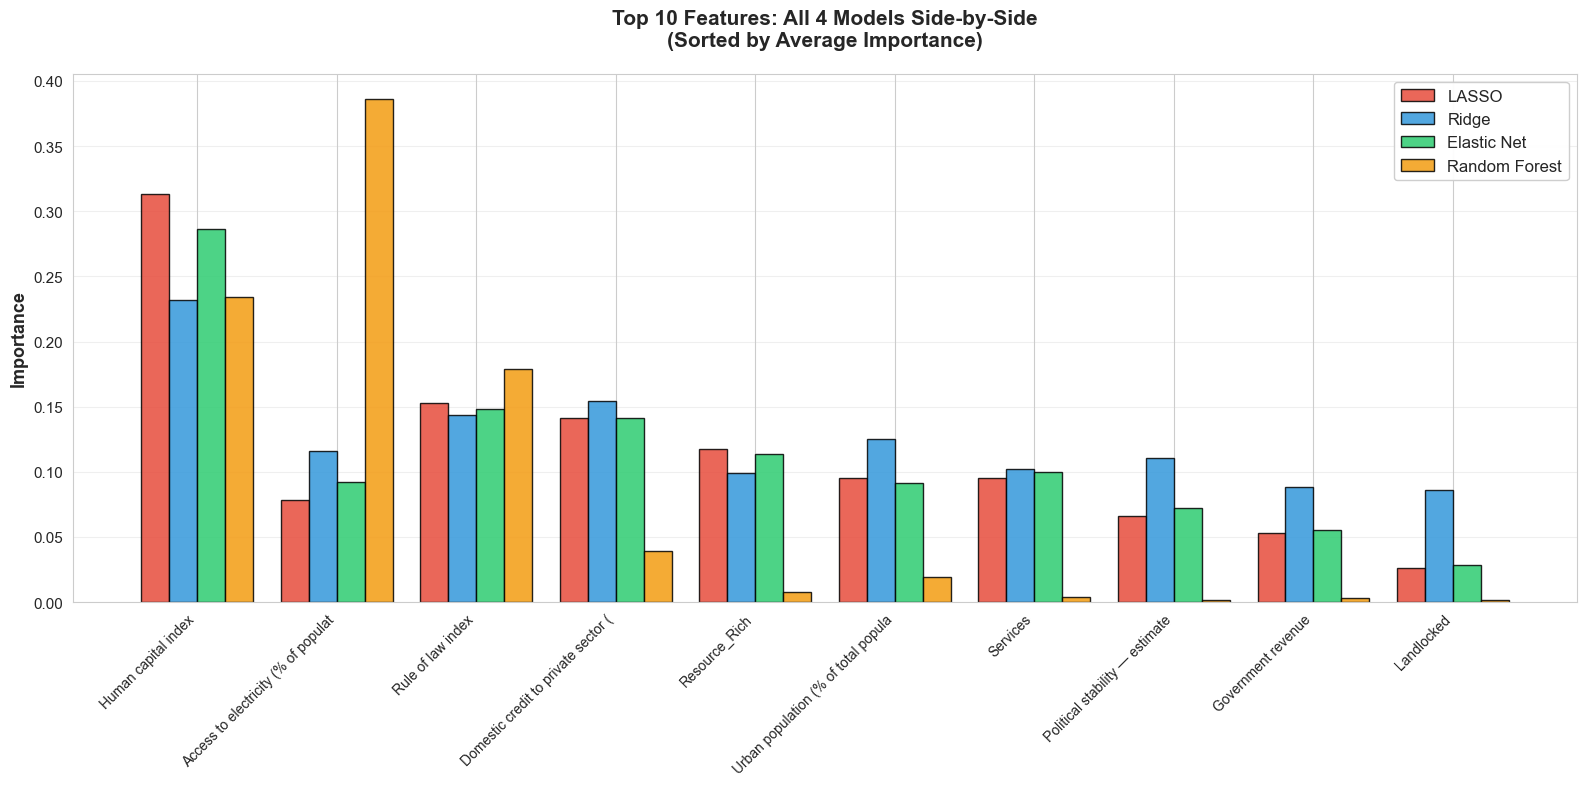


[6/6] Model agreement plot...


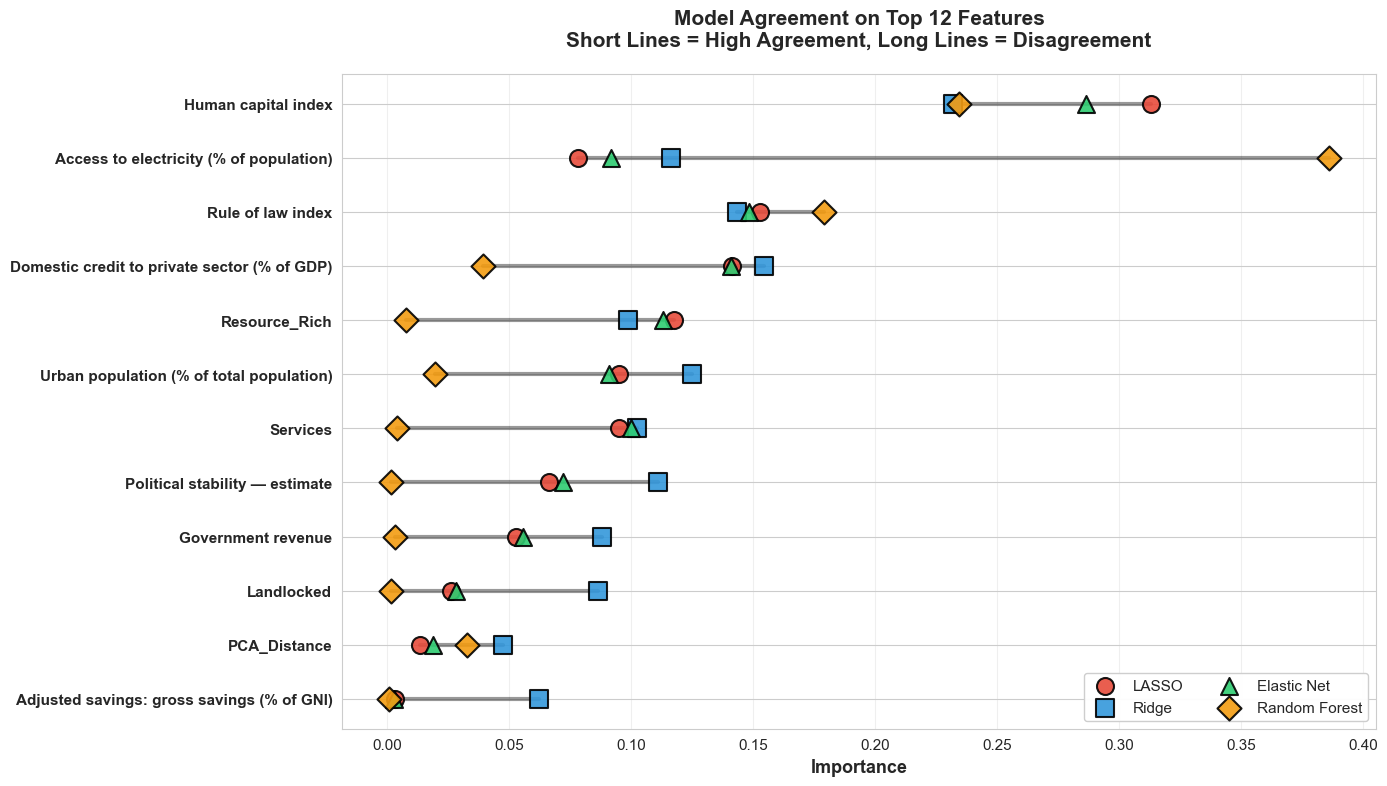


Model Performance:
        Model  Test_R2  Train_R2
Random Forest   0.7540    0.8517
  Elastic Net   0.6632    0.7311
        LASSO   0.6627    0.7316
        Ridge   0.6598    0.7524

TOP 10 CONSENSUS (Average Across All Models):

1. Human capital index
   LASSO: 0.3134, Ridge: 0.2319, Elastic: 0.2867, RF: 0.2345
   Average: 0.2666
   Agreement: High (CV=0.13)

2. Access to electricity (% of population)
   LASSO: 0.0785, Ridge: 0.1162, Elastic: 0.0919, RF: 0.3861
   Average: 0.1682
   Agreement: Low (CV=0.75)

3. Rule of law index
   LASSO: 0.1530, Ridge: 0.1435, Elastic: 0.1483, RF: 0.1790
   Average: 0.1560
   Agreement: High (CV=0.09)

4. Domestic credit to private sector (% of GDP)
   LASSO: 0.1415, Ridge: 0.1546, Elastic: 0.1412, RF: 0.0395
   Average: 0.1192
   Agreement: Medium (CV=0.39)

5. Resource_Rich
   LASSO: 0.1175, Ridge: 0.0989, Elastic: 0.1133, RF: 0.0078
   Average: 0.0844
   Agreement: Medium (CV=0.53)

6. Urban population (% of total population)
   LASSO: 0.0953, 

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')
from matplotlib.patches import Patch

sns.set_style("whitegrid")

# LOAD DATA

print(f"Master: {len(master)} obs, {master['Country Code'].nunique()} countries")

# PREPARE PANEL
df = master[(master['Year'] >= 1995) & (master['Year'] <= 2019)].dropna(subset=['Economic Complexity Index']).copy()
df = df.sort_values(['Country Code', 'Year'])
resource_rich_countries = master[master['Year'] == 1995][
    master[master['Year'] == 1995]['Total natural resources rents (% of GDP)'] >= 5
]['Country Code'].unique()
df['Resource_Rich'] = df['Country Code'].isin(resource_rich_countries).astype(int)

# Merge STATIC PCA from 1995 and 2019 (not time-varying!)
pca_1995 = c1995[['Country Code', 'PC1', 'PC2']].rename(
    columns={'PC1': 'PC1_1995', 'PC2': 'PC2_1995'}
)
pca_2019 = c2019[['Country Code', 'PC1', 'PC2']].rename(
    columns={'PC1': 'PC1_2019', 'PC2': 'PC2_2019'}
)

df = df.merge(pca_1995, on='Country Code', how='left')
df = df.merge(pca_2019, on='Country Code', how='left')

# STATIC PCA Distance (endpoint transformation 1995→2019)
df['PCA_Distance'] = np.sqrt(
    (df['PC1_2019'] - df['PC1_1995'])**2 +
    (df['PC2_2019'] - df['PC2_1995'])**2
)

print("Using STATIC PCA: PC1_1995, PC2_1995, PC1_2019, PC2_2019, PCA_Distance")

# Interactions
df['HCI_x_ProductionValue'] = df['Human capital index'] * df['Total_Production_Value']
df['RuleOfLaw_x_ProductionValue'] = df['Rule of law index'] * df['Total_Production_Value']

# FEATURES (with STATIC PCA, not time-varying)
base_features = [
    'Human capital index', 'Rule of law index', 'Political stability — estimate',
    'Trade (% of GDP)', 'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Share of investment in GDP',
    'Domestic credit to private sector (% of GDP)', 'Landlocked',
    'Urban population (% of total population)', 'Government revenue',
    'Capital depreciation rate', 'Use of IMF credit (DOD, current US$)', 'Services',
    'Real interest rate (%)', 'Inflation, consumer prices (annual %)',
    'Access to electricity (% of population)', 'Adjusted savings: gross savings (% of GNI)'
]

# Add STATIC PCA features (endpoint values)
pca_features = ['PC1_1995', 'PC2_1995', 'PC1_2019', 'PC2_2019', 'PCA_Distance']

all_features = base_features + pca_features + ['Resource_Rich',
                                'HCI_x_ProductionValue', 'RuleOfLaw_x_ProductionValue']

print(f"Total features: {len(all_features)} (17 base + 5 PCA + 1 group + 2 interactions)")

y = df['Economic Complexity Index'].values
X = df[all_features].copy()
years = df['Year'].values

# Fill PCA missing
for col in X.columns:
    if 'PC' in col:
        X[col] = X[col].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

# Split
train_mask = years <= 2014
X_train, X_test = X_scaled[train_mask], X_scaled[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

# Train
tscv = TimeSeriesSplit(n_splits=5)
lasso = LassoCV(cv=tscv, random_state=42, max_iter=10000).fit(X_train, y_train)
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=tscv).fit(X_train, y_train)
elastic = ElasticNetCV(cv=tscv, random_state=42, max_iter=10000).fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=10, 
                           random_state=42, n_jobs=-1, oob_score=True).fit(X_train, y_train)

models = {'LASSO': lasso, 'Ridge': ridge, 'Elastic Net': elastic, 'Random Forest': rf}

print("All models trained")

# Collect importance
all_importance = pd.DataFrame({'Feature': all_features})
for name, model in models.items():
    if name in ['LASSO', 'Ridge', 'Elastic Net']:
        all_importance[name] = np.abs(model.coef_)
    else:
        all_importance[name] = model.feature_importances_
all_importance['Average'] = all_importance[['LASSO', 'Ridge', 'Elastic Net', 'Random Forest']].mean(axis=1)

# Performance
perf = []
for name, model in models.items():
    perf.append({
        'Model': name,
        'Test_R2': model.score(X_test, y_test),
        'Train_R2': model.score(X_train, y_train)
    })
perf_df = pd.DataFrame(perf).sort_values('Test_R2', ascending=False)

print("Importance collected from all models")


# VISUALIZATION 1: 4-Panel Top 15
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for idx, model_name in enumerate(['LASSO', 'Ridge', 'Elastic Net', 'Random Forest']):
    ax = axes[idx]
    
    model_sorted = all_importance.sort_values(model_name, ascending=False).head(15)
    colors = []
    labels = []
    for feat in model_sorted['Feature']:
        if 'PCA' in feat or ('PC' in feat and '_x_' not in feat):
            colors.append('#9B59B6')
            label_text = f"{feat[:32]}"
        elif '_x_' in feat:
            colors.append('#F39C12')
            label_text = f"{feat.replace('_x_', '×')[:32]}"
        elif 'Resource_Rich' in feat:
            colors.append('#E74C3C')
            label_text = f"{feat[:32]}"
        else:
            colors.append('#3498DB')
            label_text = f"   {feat[:32]}"
        labels.append(label_text)
    
    y_pos = np.arange(len(model_sorted))
    bars = ax.barh(y_pos, model_sorted[model_name], color=colors, alpha=0.85, 
                  edgecolor='black', linewidth=1.2)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Importance', fontsize=11, fontweight='bold')
    test_r2 = perf_df[perf_df['Model'] == model_name]['Test_R2'].values[0]
    n_features = len(all_features) if model_name in ['Ridge', 'Random Forest'] else np.sum(all_importance[model_name] != 0)
    ax.set_title(f'{model_name}\nTest R²={test_r2:.3f}, Features={n_features}', 
                fontsize=13, fontweight='bold', pad=10)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    
    # Add values for top 5
    for i in range(min(5, len(bars))):
        val = model_sorted[model_name].iloc[i]
        if val > 0.01:
            ax.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=9, fontweight='bold')


fig.legend(handles=[
    Patch(facecolor='#3498DB', label='Base Features', alpha=0.85, edgecolor='black'),
    Patch(facecolor='#9B59B6', label='PCA (1995 & 2019) ', alpha=0.85, edgecolor='black'),
    Patch(facecolor='#E74C3C', label='Resource_Rich ', alpha=0.85, edgecolor='black'),
    Patch(facecolor='#F39C12', label='Interactions ', alpha=0.85, edgecolor='black')
], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=12, framealpha=0.95)

plt.suptitle('Feature Importance: All 4 Models (Top 15)\nStatic PCA (1995 & 2019), Time Series CV', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0.02, 1, 0.99])
plt.show()

# VISUALIZATION 2: Heatmap (Top 20)
print("\n[2/6] Heatmap (top 20 features)...")

fig, ax = plt.subplots(figsize=(14, 10))

top_20 = all_importance.sort_values('Average', ascending=False).head(20)
heatmap_matrix = top_20[['LASSO', 'Ridge', 'Elastic Net', 'Random Forest']].T

sns.heatmap(heatmap_matrix, annot=True, fmt='.3f', cmap='YlOrRd', 
           cbar_kws={'label': 'Importance', 'shrink': 0.8}, 
           linewidths=1, linecolor='white',
           xticklabels=[f[:35] for f in top_20['Feature']],
           yticklabels=['LASSO', 'Ridge', 'Elastic Net', 'Random Forest'],
           ax=ax, vmin=0, vmax=0.4)

ax.set_title('Feature Importance Heatmap: Top 20 Features × All 4 Models\nYellow=Low, Red=High', 
            fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Features (Sorted by Average Importance)', fontsize=12, fontweight='bold')
ax.set_ylabel('Models', fontsize=12, fontweight='bold')

plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

# VISUALIZATION 3: Grouped Bar (Top 10)

print("\n[3/6] Grouped bar chart (top 10)...")

fig, ax = plt.subplots(figsize=(16, 8))

top_10 = all_importance.sort_values('Average', ascending=False).head(10)

x = np.arange(len(top_10))
width = 0.2

ax.bar(x - 1.5*width, top_10['LASSO'], width, label='LASSO', 
      alpha=0.85, edgecolor='black', linewidth=1, color='#E74C3C')
ax.bar(x - 0.5*width, top_10['Ridge'], width, label='Ridge', 
      alpha=0.85, edgecolor='black', linewidth=1, color='#3498DB')
ax.bar(x + 0.5*width, top_10['Elastic Net'], width, label='Elastic Net', 
      alpha=0.85, edgecolor='black', linewidth=1, color='#2ECC71')
ax.bar(x + 1.5*width, top_10['Random Forest'], width, label='Random Forest', 
      alpha=0.85, edgecolor='black', linewidth=1, color='#F39C12')

ax.set_xticks(x)
ax.set_xticklabels([f[:35] for f in top_10['Feature']], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Importance', fontsize=13, fontweight='bold')
ax.set_title('Top 10 Features: All 4 Models Side-by-Side\n(Sorted by Average Importance)', 
            fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper right', framealpha=0.95)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# VISUALIZATION 6: Model Agreement with Ranges

print("\n[6/6] Model agreement plot...")

fig, ax = plt.subplots(figsize=(14, 8))

top_12 = all_importance.sort_values('Average', ascending=False).head(12)

# For each feature, plot model values and range
y_pos = np.arange(len(top_12))

for i, (_, row) in enumerate(top_12.iterrows()):
    vals = [row['LASSO'], row['Ridge'], row['Elastic Net'], row['Random Forest']]
    
    # Plot range line
    ax.plot([min(vals), max(vals)], [i, i], 'k-', alpha=0.4, linewidth=3, zorder=1)
    
    # Plot model points
    ax.scatter(row['LASSO'], i, marker='o', s=150, alpha=0.9, 
              color='#E74C3C', edgecolor='black', linewidth=1.5, zorder=3, label='LASSO' if i==0 else '')
    ax.scatter(row['Ridge'], i, marker='s', s=150, alpha=0.9, 
              color='#3498DB', edgecolor='black', linewidth=1.5, zorder=3, label='Ridge' if i==0 else '')
    ax.scatter(row['Elastic Net'], i, marker='^', s=150, alpha=0.9, 
              color='#2ECC71', edgecolor='black', linewidth=1.5, zorder=3, label='Elastic Net' if i==0 else '')
    ax.scatter(row['Random Forest'], i, marker='D', s=150, alpha=0.9, 
              color='#F39C12', edgecolor='black', linewidth=1.5, zorder=3, label='Random Forest' if i==0 else '')

ax.set_yticks(y_pos)
ax.set_yticklabels([f[:45] for f in top_12['Feature']], fontsize=11, fontweight='bold')
ax.set_xlabel('Importance', fontsize=13, fontweight='bold')
ax.set_title('Model Agreement on Top 12 Features\nShort Lines = High Agreement, Long Lines = Disagreement', 
            fontsize=15, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.legend(fontsize=11, loc='lower right', framealpha=0.95, ncol=2)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


# SUMMARY STATISTICS
print("\nModel Performance:")
print(perf_df.to_string(index=False, float_format='%.4f'))

print("\n" + "="*80)
print("TOP 10 CONSENSUS (Average Across All Models):")
print("="*80)

for i, (_, row) in enumerate(top_10.iterrows(), 1):
    print(f"\n{i}. {row['Feature']}")
    print(f"   LASSO: {row['LASSO']:.4f}, Ridge: {row['Ridge']:.4f}, "
          f"Elastic: {row['Elastic Net']:.4f}, RF: {row['Random Forest']:.4f}")
    print(f"   Average: {row['Average']:.4f}")
    
    # Calculate coefficient of variation (measure of agreement)
    vals = [row['LASSO'], row['Ridge'], row['Elastic Net'], row['Random Forest']]
    cv = np.std(vals) / np.mean(vals) if np.mean(vals) > 0 else 0
    agreement = "High" if cv < 0.3 else "Medium" if cv < 0.6 else "Low"
    print(f"   Agreement: {agreement} (CV={cv:.2f})")

print("\n" + "="*80)
print("PCA COMPONENTS (All Models):")
print("="*80)

for feat in ['PC1_1995', 'PC2_1995', 'PC1_2019', 'PC2_2019', 'PCA_Distance']:
    if feat in all_importance['Feature'].values:
        row = all_importance[all_importance['Feature'] == feat].iloc[0]
        rank = all_importance.sort_values('Average', ascending=False)[
            all_importance.sort_values('Average', ascending=False)['Feature'] == feat
        ].index[0] + 1
        
        print(f"\n{feat}:")
        print(f"   LASSO: {row['LASSO']:.4f}, Ridge: {row['Ridge']:.4f}, "
              f"Elastic: {row['Elastic Net']:.4f}, RF: {row['Random Forest']:.4f}")
        print(f"   Average: {row['Average']:.4f} (Rank #{rank}/{len(all_features)})")

# Tried generating the PCA for every year

Master: 3150 obs, 126 countries

Available production columns:
  - Total_Production
  - Total_Reserves
  - Total_Production_Value
  - Total_Reserves_Value
Countries with production data: 126

Individual mineral production columns found: 0
All models trained
Importance collected from all models


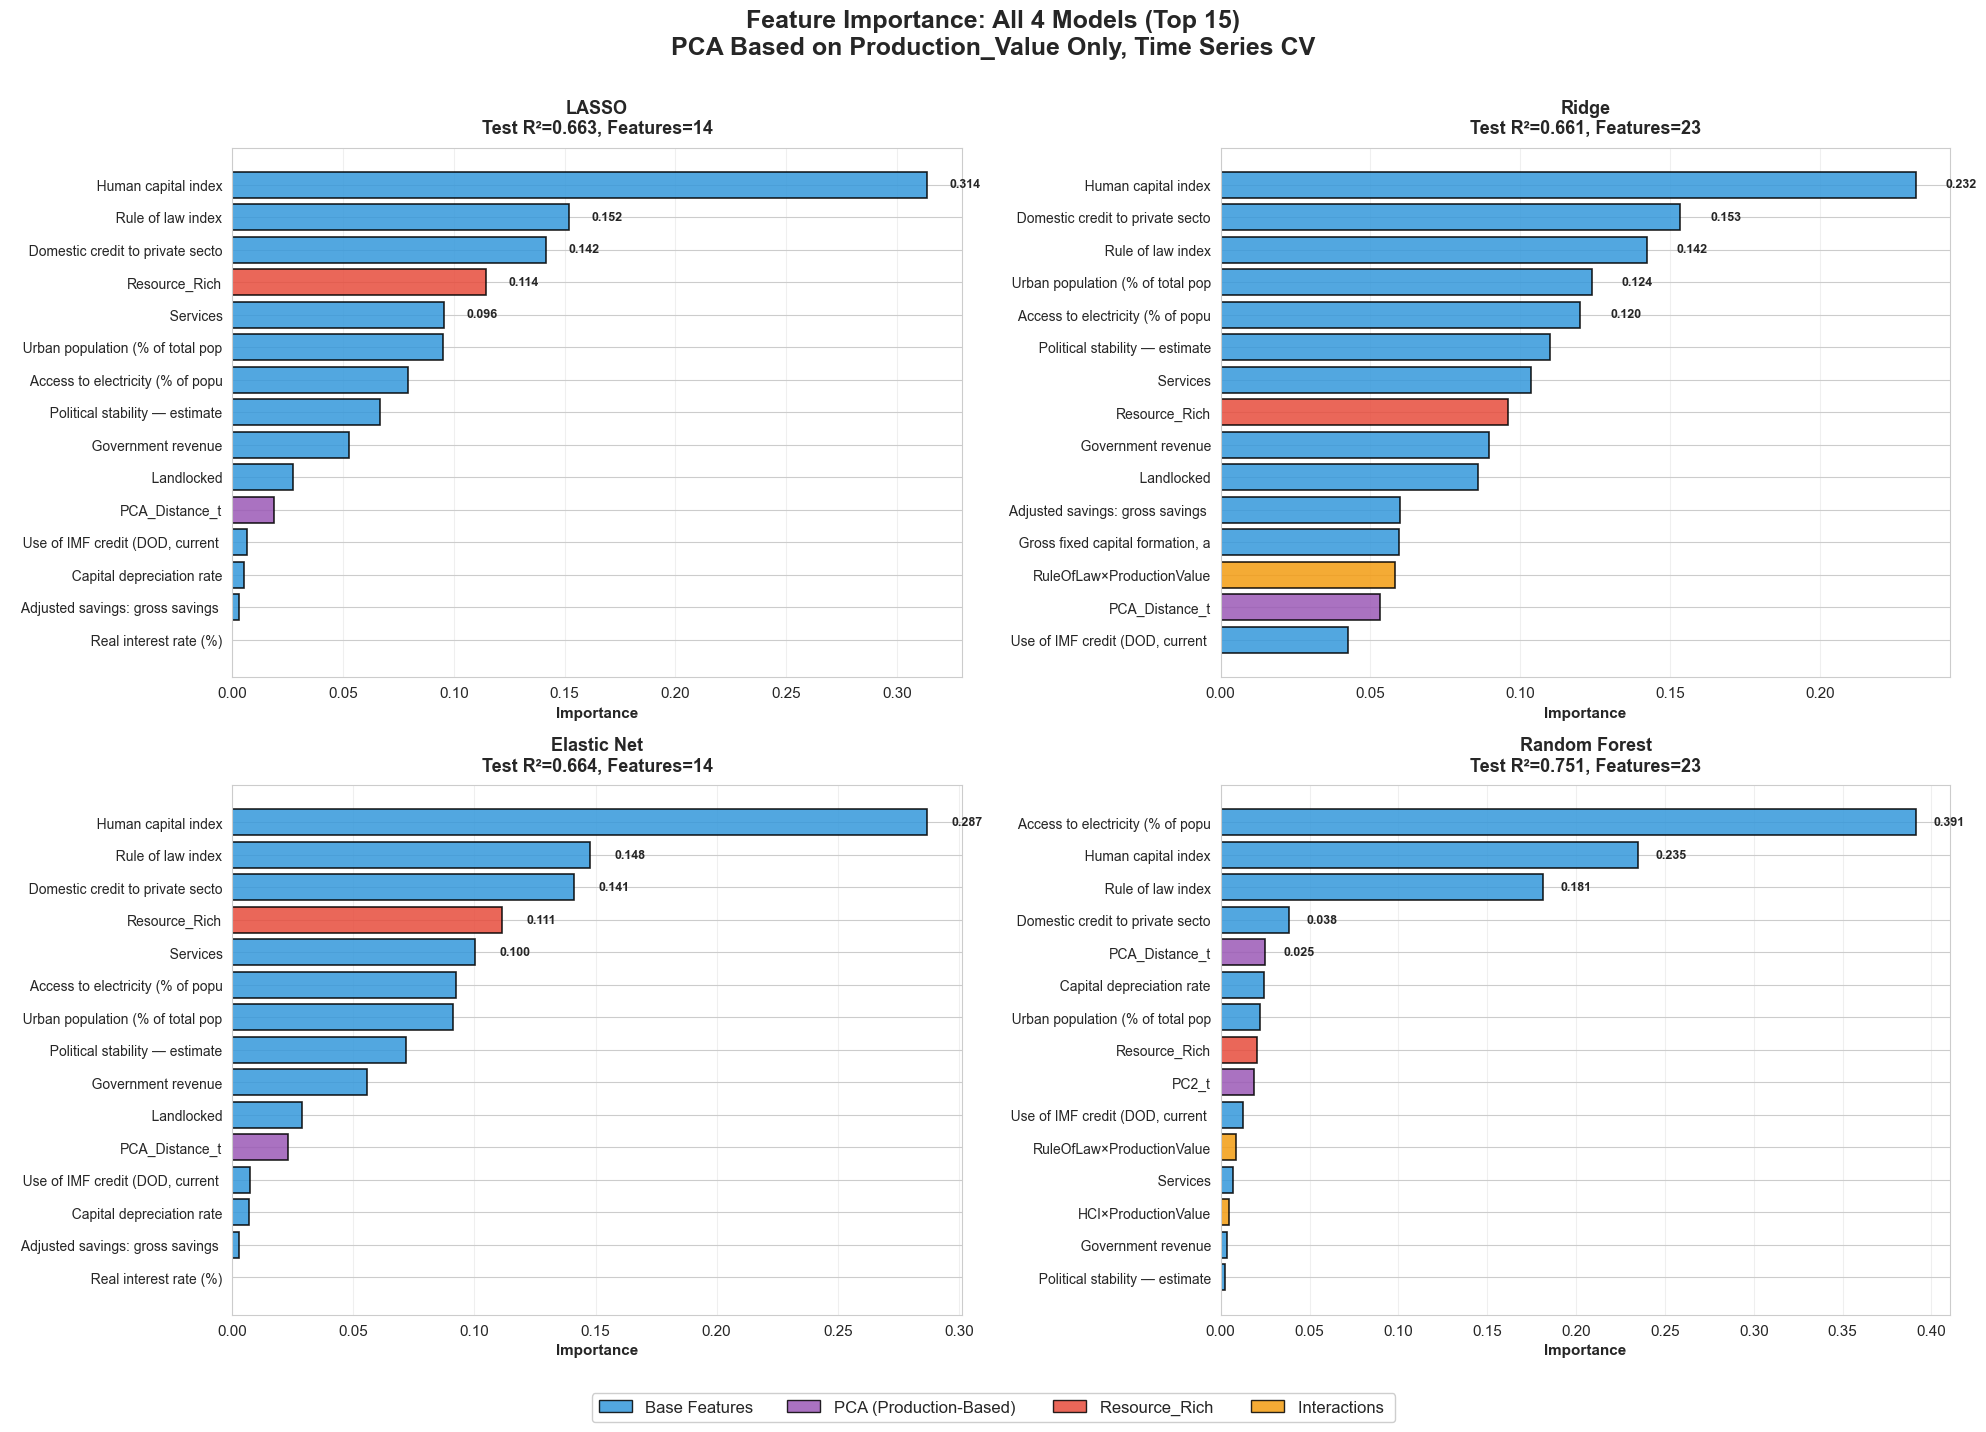


[2/6] Heatmap (top 20 features)...


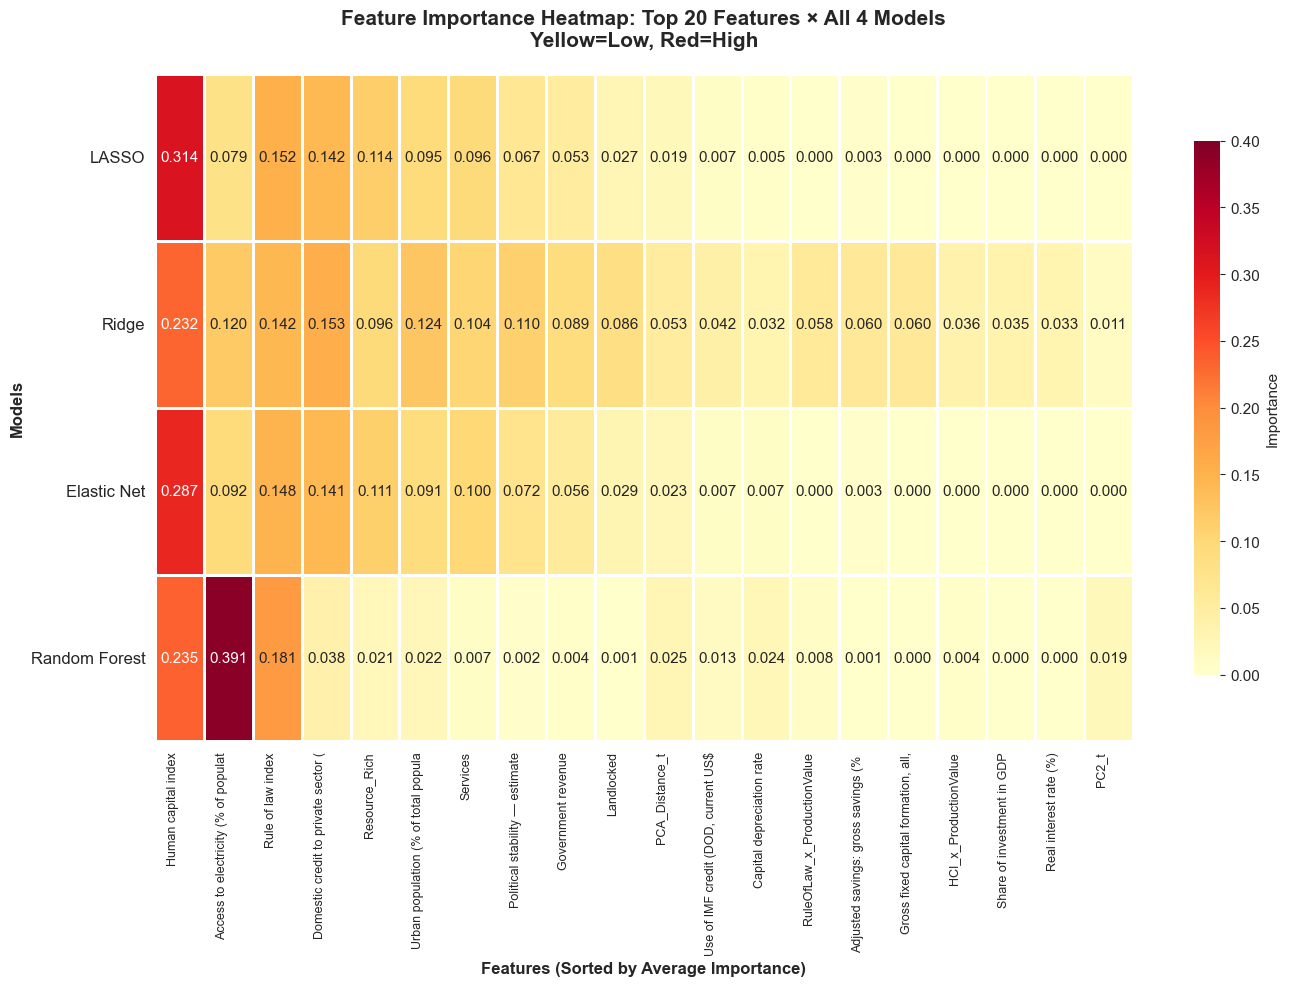


[3/6] Grouped bar chart (top 10)...


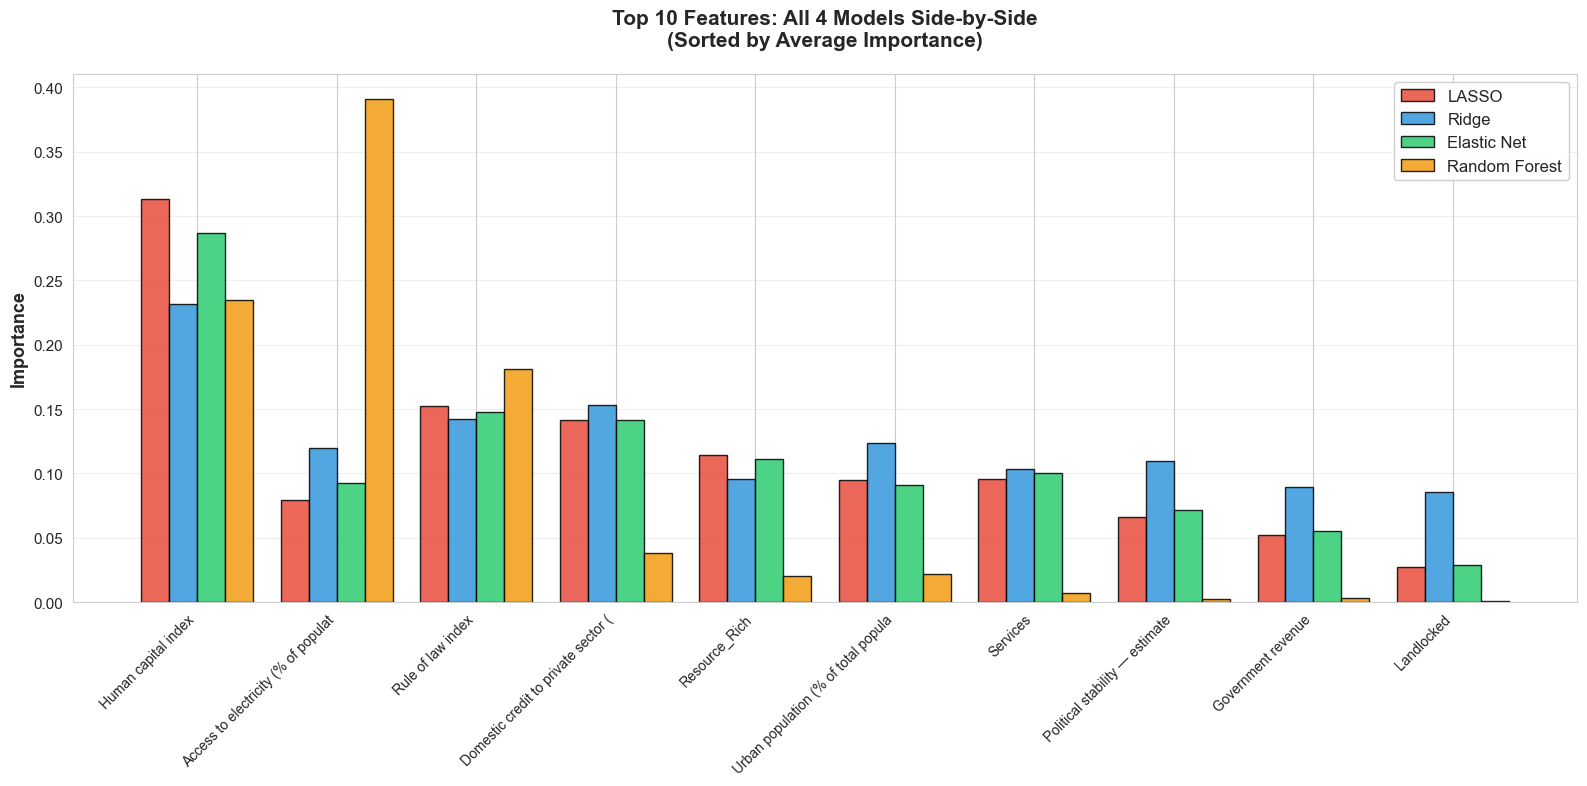


[5/6] Consensus ranking (top 15 with model details)...


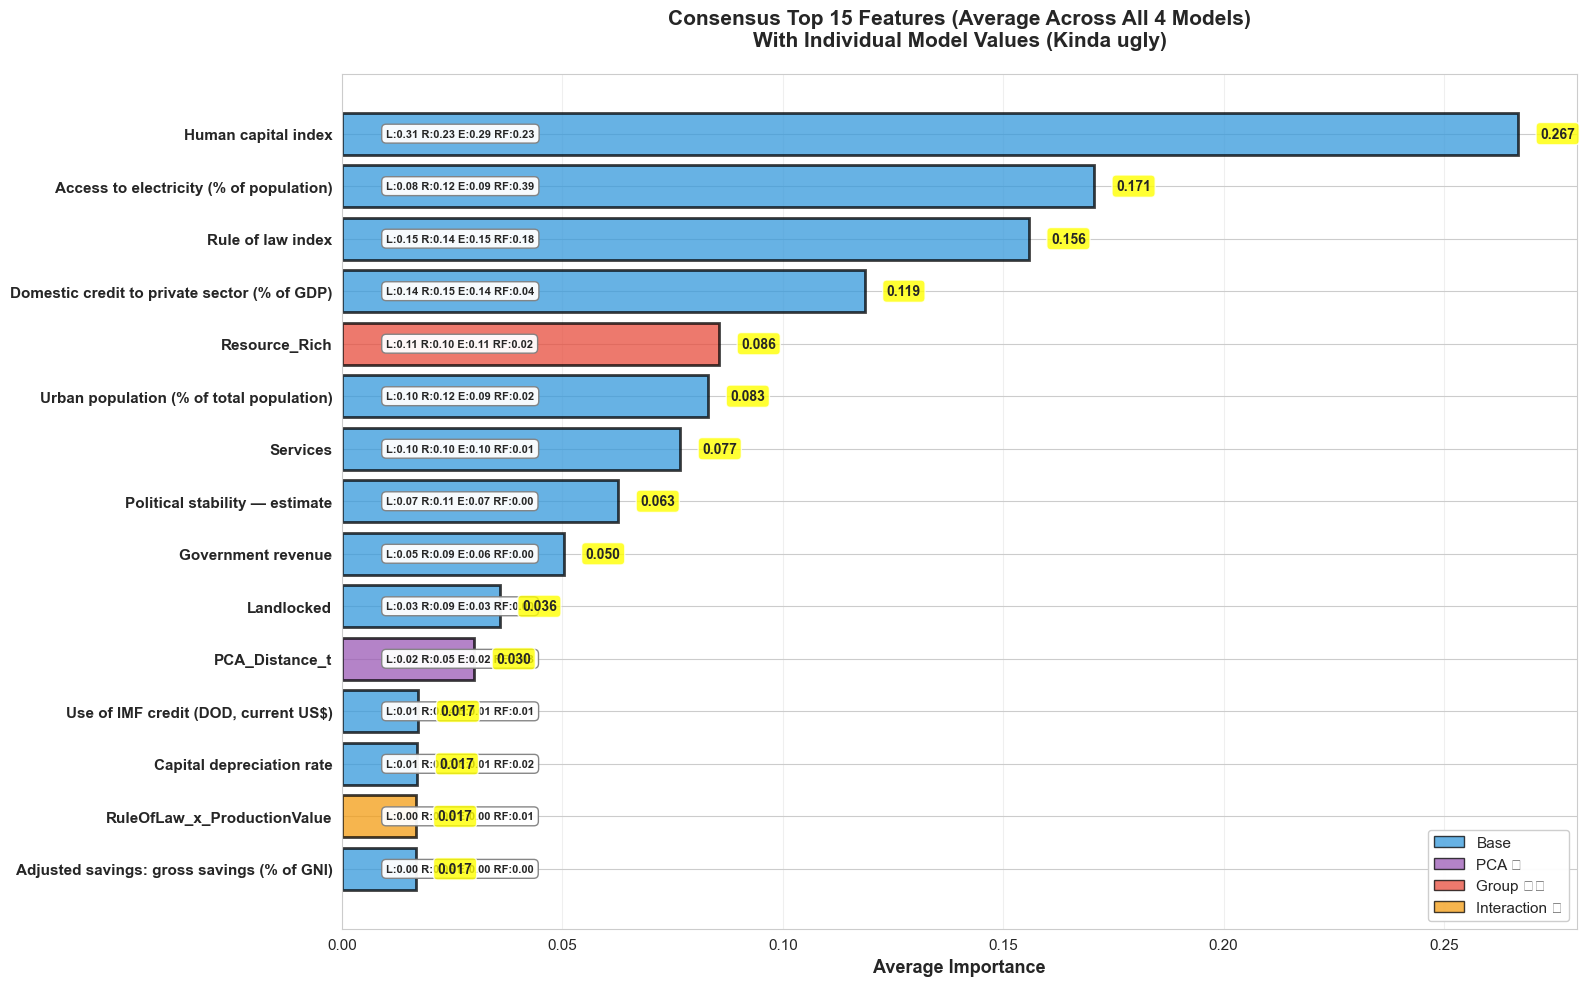


[6/6] Model agreement plot...


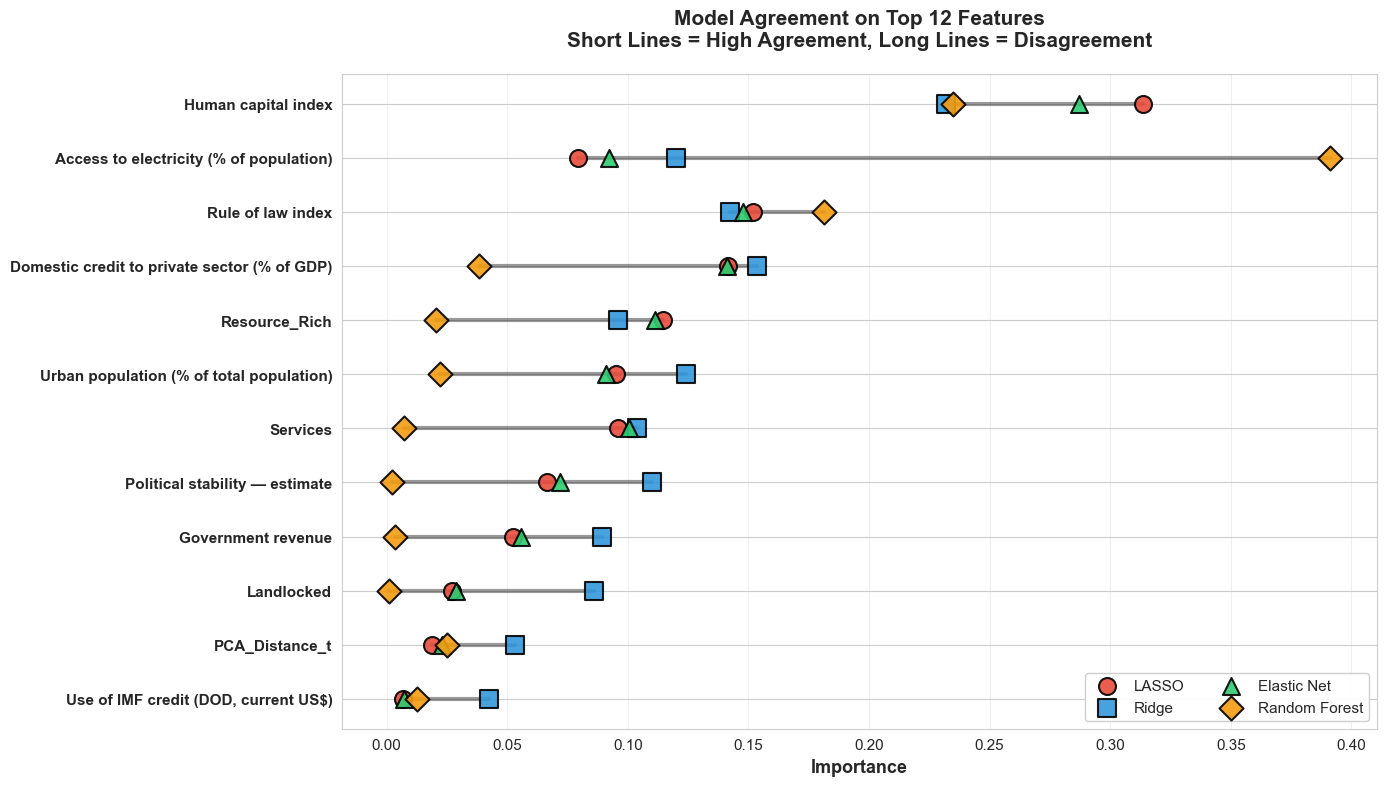


Model Performance:
        Model  Test_R2  Train_R2
Random Forest   0.7513    0.8507
  Elastic Net   0.6637    0.7313
        LASSO   0.6632    0.7319
        Ridge   0.6610    0.7523

TOP 10 CONSENSUS (Average Across All Models):

1. Human capital index
   LASSO: 0.3136, Ridge: 0.2320, Elastic: 0.2869, RF: 0.2349
   Average: 0.2669
   Agreement: High (CV=0.13)

2. Access to electricity (% of population)
   LASSO: 0.0792, Ridge: 0.1200, Elastic: 0.0923, RF: 0.3911
   Average: 0.1706
   Agreement: ✗Low (CV=0.75)

3. Rule of law index
   LASSO: 0.1521, Ridge: 0.1422, Elastic: 0.1477, RF: 0.1814
   Average: 0.1558
   Agreement: High (CV=0.10)

4. Domestic credit to private sector (% of GDP)
   LASSO: 0.1416, Ridge: 0.1534, Elastic: 0.1413, RF: 0.0382
   Average: 0.1186
   Agreement:  Medium (CV=0.39)

5. Resource_Rich
   LASSO: 0.1144, Ridge: 0.0958, Elastic: 0.1114, RF: 0.0207
   Average: 0.0856
   Agreement:  Medium (CV=0.45)

6. Urban population (% of total population)
   LASSO: 0.095

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')
from matplotlib.patches import Patch

sns.set_style("whitegrid")

# LOAD DATA

print(f"Master: {len(master)} obs, {master['Country Code'].nunique()} countries")


# Get 1995 data
df_1995 = master[master['Year'] == 1995].copy()
print("\nAvailable production columns:")
for col in master.columns:
    if 'Production' in col or 'Reserves' in col:
        if 'Total' in col:
            print(f"  - {col}")
# Use Total_Production_Value
production_data_1995 = df_1995[['Country Code', 'Total_Production_Value']].dropna()
print(f"Countries with production data: {len(production_data_1995)}")

# Option A: If you have individual mineral production values
mineral_cols = [col for col in master.columns if 
                ('Production' in col or 'production' in col) and 
                col not in ['Total_Production', 'Total_Production_Value']]

print(f"\nIndividual mineral production columns found: {len(mineral_cols)}")
if len(mineral_cols) > 0:
    print(f"  Examples: {mineral_cols[:5]}")

# PREPARE PANEL
df = master[(master['Year'] >= 1995) & (master['Year'] <= 2019)].dropna(subset=['Economic Complexity Index']).copy()
df = df.sort_values(['Country Code', 'Year'])
resource_rich_countries = master[master['Year'] == 1995][
    master[master['Year'] == 1995]['Total natural resources rents (% of GDP)'] >= 5
]['Country Code'].unique()
df['Resource_Rich'] = df['Country Code'].isin(resource_rich_countries).astype(int)

# Merge PCA (based on production_value)
pca_1995 = c1995[['Country Code', 'PC1', 'PC2']].rename(
    columns={'PC1': 'PC1_1995', 'PC2': 'PC2_1995'}
)
pca_2019 = c2019[['Country Code', 'PC1', 'PC2']].rename(
    columns={'PC1': 'PC1_2019', 'PC2': 'PC2_2019'}
)

df = df.merge(pca_1995, on='Country Code', how='left')
df = df.merge(pca_2019, on='Country Code', how='left')

# Time-varying PCA
df['PC1_t'] = np.where(df['Year'] >= 1996, df['PC1_2019'], df['PC1_1995'])
df['PC2_t'] = np.where(df['Year'] >= 1996, df['PC2_2019'], df['PC2_1995'])

# Time-varying distance (no future info!)
df['PCA_Distance_t'] = np.sqrt(
    (df['PC1_t'] - df['PC1_1995'])**2 +
    (df['PC2_t'] - df['PC2_1995'])**2
)
# Interactions
df['HCI_x_ProductionValue'] = df['Human capital index'] * df['Total_Production_Value']
df['RuleOfLaw_x_ProductionValue'] = df['Rule of law index'] * df['Total_Production_Value']
df['PC1_x_HC'] = df['PC1_t'] * df['Human capital index']
df['PC2_x_Governance'] = df['PC2_t'] * df['Rule of law index']


# FEATURES
base_features = [
    'Human capital index', 'Rule of law index', 'Political stability — estimate',
    'Trade (% of GDP)', 'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Share of investment in GDP',
    'Domestic credit to private sector (% of GDP)', 'Landlocked',
    'Urban population (% of total population)', 'Government revenue',
    'Capital depreciation rate', 'Use of IMF credit (DOD, current US$)', 'Services',
    'Real interest rate (%)', 'Inflation, consumer prices (annual %)',
    'Access to electricity (% of population)', 'Adjusted savings: gross savings (% of GNI)'
]

# I only tested these interactions btw
all_features = base_features + ['PC1_t','PC2_t', 'PCA_Distance_t','Resource_Rich',
                                'HCI_x_ProductionValue', 'RuleOfLaw_x_ProductionValue',]

y = df['Economic Complexity Index'].values
X = df[all_features].copy()
years = df['Year'].values

for col in X.columns:
    if 'PC' in col:
        X[col] = X[col].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

# Split
train_mask = years <= 2014
X_train, X_test = X_scaled[train_mask], X_scaled[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

# Train
tscv = TimeSeriesSplit(n_splits=5)
lasso = LassoCV(cv=tscv, random_state=42, max_iter=10000).fit(X_train, y_train)
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=tscv).fit(X_train, y_train)
elastic = ElasticNetCV(cv=tscv, random_state=42, max_iter=10000).fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=10, 
                           random_state=42, n_jobs=-1, oob_score=True).fit(X_train, y_train)

models = {'LASSO': lasso, 'Ridge': ridge, 'Elastic Net': elastic, 'Random Forest': rf}

print("All models trained")

# Collect importance
all_importance = pd.DataFrame({'Feature': all_features})
for name, model in models.items():
    if name in ['LASSO', 'Ridge', 'Elastic Net']:
        all_importance[name] = np.abs(model.coef_)
    else:
        all_importance[name] = model.feature_importances_
all_importance['Average'] = all_importance[['LASSO', 'Ridge', 'Elastic Net', 'Random Forest']].mean(axis=1)

# Performance
perf = []
for name, model in models.items():
    perf.append({
        'Model': name,
        'Test_R2': model.score(X_test, y_test),
        'Train_R2': model.score(X_train, y_train)
    })
perf_df = pd.DataFrame(perf).sort_values('Test_R2', ascending=False)

print("Importance collected from all models")


# VISUALIZATION 1: 4-Panel Top 15
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for idx, model_name in enumerate(['LASSO', 'Ridge', 'Elastic Net', 'Random Forest']):
    ax = axes[idx]
    
    model_sorted = all_importance.sort_values(model_name, ascending=False).head(15)
    colors = []
    labels = []
    for feat in model_sorted['Feature']:
        if 'PCA' in feat or ('PC' in feat and '_x_' not in feat):
            colors.append('#9B59B6')
            label_text = f"{feat[:32]}"
        elif '_x_' in feat:
            colors.append('#F39C12')
            label_text = f"{feat.replace('_x_', '×')[:32]}"
        elif 'Resource_Rich' in feat:
            colors.append('#E74C3C')
            label_text = f"{feat[:32]}"
        else:
            colors.append('#3498DB')
            label_text = f"   {feat[:32]}"
        labels.append(label_text)
    
    y_pos = np.arange(len(model_sorted))
    bars = ax.barh(y_pos, model_sorted[model_name], color=colors, alpha=0.85, 
                  edgecolor='black', linewidth=1.2)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Importance', fontsize=11, fontweight='bold')
    test_r2 = perf_df[perf_df['Model'] == model_name]['Test_R2'].values[0]
    n_features = len(all_features) if model_name in ['Ridge', 'Random Forest'] else np.sum(all_importance[model_name] != 0)
    ax.set_title(f'{model_name}\nTest R²={test_r2:.3f}, Features={n_features}', 
                fontsize=13, fontweight='bold', pad=10)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    
    # Add values for top 5
    for i in range(min(5, len(bars))):
        val = model_sorted[model_name].iloc[i]
        if val > 0.01:
            ax.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=9, fontweight='bold')


fig.legend(handles=[
    Patch(facecolor='#3498DB', label='Base Features', alpha=0.85, edgecolor='black'),
    Patch(facecolor='#9B59B6', label='PCA (Production-Based) ', alpha=0.85, edgecolor='black'),
    Patch(facecolor='#E74C3C', label='Resource_Rich ', alpha=0.85, edgecolor='black'),
    Patch(facecolor='#F39C12', label='Interactions ', alpha=0.85, edgecolor='black')
], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=12, framealpha=0.95)

plt.suptitle('Feature Importance: All 4 Models (Top 15)\nPCA Based on Production_Value Only, Time Series CV', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0.02, 1, 0.99])
plt.show()

# VISUALIZATION 2: Heatmap (Top 20)
print("\n[2/6] Heatmap (top 20 features)...")

fig, ax = plt.subplots(figsize=(14, 10))

top_20 = all_importance.sort_values('Average', ascending=False).head(20)
heatmap_matrix = top_20[['LASSO', 'Ridge', 'Elastic Net', 'Random Forest']].T

sns.heatmap(heatmap_matrix, annot=True, fmt='.3f', cmap='YlOrRd', 
           cbar_kws={'label': 'Importance', 'shrink': 0.8}, 
           linewidths=1, linecolor='white',
           xticklabels=[f[:35] for f in top_20['Feature']],
           yticklabels=['LASSO', 'Ridge', 'Elastic Net', 'Random Forest'],
           ax=ax, vmin=0, vmax=0.4)

ax.set_title('Feature Importance Heatmap: Top 20 Features × All 4 Models\nYellow=Low, Red=High', 
            fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Features (Sorted by Average Importance)', fontsize=12, fontweight='bold')
ax.set_ylabel('Models', fontsize=12, fontweight='bold')

plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

# VISUALIZATION 3: Grouped Bar (Top 10)

print("\n[3/6] Grouped bar chart (top 10)...")

fig, ax = plt.subplots(figsize=(16, 8))

top_10 = all_importance.sort_values('Average', ascending=False).head(10)

x = np.arange(len(top_10))
width = 0.2

ax.bar(x - 1.5*width, top_10['LASSO'], width, label='LASSO', 
      alpha=0.85, edgecolor='black', linewidth=1, color='#E74C3C')
ax.bar(x - 0.5*width, top_10['Ridge'], width, label='Ridge', 
      alpha=0.85, edgecolor='black', linewidth=1, color='#3498DB')
ax.bar(x + 0.5*width, top_10['Elastic Net'], width, label='Elastic Net', 
      alpha=0.85, edgecolor='black', linewidth=1, color='#2ECC71')
ax.bar(x + 1.5*width, top_10['Random Forest'], width, label='Random Forest', 
      alpha=0.85, edgecolor='black', linewidth=1, color='#F39C12')

ax.set_xticks(x)
ax.set_xticklabels([f[:35] for f in top_10['Feature']], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Importance', fontsize=13, fontweight='bold')
ax.set_title('Top 10 Features: All 4 Models Side-by-Side\n(Sorted by Average Importance)', 
            fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper right', framealpha=0.95)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# VISUALIZATION 5: Consensus Ranking 
print("\n[5/6] Consensus ranking (top 15 with model details)...")

fig, ax = plt.subplots(figsize=(16, 10))

top_15 = all_importance.sort_values('Average', ascending=False).head(15)

# Colors
colors = []
for feat in top_15['Feature']:
    if 'PC' in feat and '_x_' not in feat:
        colors.append('#9B59B6')
    elif '_x_' in feat:
        colors.append('#F39C12')
    elif 'Resource_Rich' in feat:
        colors.append('#E74C3C')
    else:
        colors.append('#3498DB')

y_pos = np.arange(len(top_15))
bars = ax.barh(y_pos, top_15['Average'], color=colors, alpha=0.75, 
              edgecolor='black', linewidth=2)

ax.set_yticks(y_pos)
ax.set_yticklabels([f[:45] for f in top_15['Feature']], fontsize=11, fontweight='bold')
ax.set_xlabel('Average Importance', fontsize=13, fontweight='bold')
ax.set_title('Consensus Top 15 Features (Average Across All 4 Models)\nWith Individual Model Values (Kinda ugly)', 
            fontsize=15, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Overlay model-specific values
for i, (_, row) in enumerate(top_15.iterrows()):
    model_values = f"L:{row['LASSO']:.2f} R:{row['Ridge']:.2f} E:{row['Elastic Net']:.2f} RF:{row['Random Forest']:.2f}"
    ax.text(0.01, i, model_values, va='center', fontsize=8, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.95, 
                    edgecolor='gray', linewidth=1))

# Add average values
for bar, avg in zip(bars, top_15['Average']):
    ax.text(avg + 0.005, bar.get_y() + bar.get_height()/2,
           f'{avg:.3f}', va='center', fontsize=10, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8))

ax.legend(handles=[
    Patch(facecolor='#3498DB', label='Base', alpha=0.75, edgecolor='black'),
    Patch(facecolor='#9B59B6', label='PCA 📊', alpha=0.75, edgecolor='black'),
    Patch(facecolor='#E74C3C', label='Group 🏷️', alpha=0.75, edgecolor='black'),
    Patch(facecolor='#F39C12', label='Interaction 🔗', alpha=0.75, edgecolor='black')
], loc='lower right', fontsize=11, framealpha=0.95)

plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 6: Model Agreement with Ranges
# ============================================================================

print("\n[6/6] Model agreement plot...")

fig, ax = plt.subplots(figsize=(14, 8))

top_12 = all_importance.sort_values('Average', ascending=False).head(12)

# For each feature, plot model values and range
y_pos = np.arange(len(top_12))

for i, (_, row) in enumerate(top_12.iterrows()):
    vals = [row['LASSO'], row['Ridge'], row['Elastic Net'], row['Random Forest']]
    
    # Plot range line
    ax.plot([min(vals), max(vals)], [i, i], 'k-', alpha=0.4, linewidth=3, zorder=1)
    
    # Plot model points
    ax.scatter(row['LASSO'], i, marker='o', s=150, alpha=0.9, 
              color='#E74C3C', edgecolor='black', linewidth=1.5, zorder=3, label='LASSO' if i==0 else '')
    ax.scatter(row['Ridge'], i, marker='s', s=150, alpha=0.9, 
              color='#3498DB', edgecolor='black', linewidth=1.5, zorder=3, label='Ridge' if i==0 else '')
    ax.scatter(row['Elastic Net'], i, marker='^', s=150, alpha=0.9, 
              color='#2ECC71', edgecolor='black', linewidth=1.5, zorder=3, label='Elastic Net' if i==0 else '')
    ax.scatter(row['Random Forest'], i, marker='D', s=150, alpha=0.9, 
              color='#F39C12', edgecolor='black', linewidth=1.5, zorder=3, label='Random Forest' if i==0 else '')

ax.set_yticks(y_pos)
ax.set_yticklabels([f[:45] for f in top_12['Feature']], fontsize=11, fontweight='bold')
ax.set_xlabel('Importance', fontsize=13, fontweight='bold')
ax.set_title('Model Agreement on Top 12 Features\nShort Lines = High Agreement, Long Lines = Disagreement', 
            fontsize=15, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.legend(fontsize=11, loc='lower right', framealpha=0.95, ncol=2)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


# SUMMARY STATISTICS

print("\nModel Performance:")
print(perf_df.to_string(index=False, float_format='%.4f'))

print("\n" + "="*80)
print("TOP 10 CONSENSUS (Average Across All Models):")
print("="*80)

for i, (_, row) in enumerate(top_10.iterrows(), 1):
    print(f"\n{i}. {row['Feature']}")
    print(f"   LASSO: {row['LASSO']:.4f}, Ridge: {row['Ridge']:.4f}, "
          f"Elastic: {row['Elastic Net']:.4f}, RF: {row['Random Forest']:.4f}")
    print(f"   Average: {row['Average']:.4f}")
    
    # Calculate coefficient of variation (measure of agreement)
    vals = [row['LASSO'], row['Ridge'], row['Elastic Net'], row['Random Forest']]
    cv = np.std(vals) / np.mean(vals) if np.mean(vals) > 0 else 0
    agreement = "High" if cv < 0.3 else " Medium" if cv < 0.6 else "✗Low"
    print(f"   Agreement: {agreement} (CV={cv:.2f})")

print("\n" + "="*80)
print("PCA COMPONENTS (All Models):")
print("="*80)

for feat in ['PC1_t', 'PC2_t', 'PCA_Distance_t']:
    row = all_importance[all_importance['Feature'] == feat].iloc[0]
    rank = all_importance.sort_values('Average', ascending=False)[
        all_importance.sort_values('Average', ascending=False)['Feature'] == feat
    ].index[0] + 1
    
    print(f"\n{feat}:")
    print(f"   LASSO: {row['LASSO']:.4f}, Ridge: {row['Ridge']:.4f}, "
          f"Elastic: {row['Elastic Net']:.4f}, RF: {row['Random Forest']:.4f}")
    print(f"   Average: {row['Average']:.4f} (Rank #{rank}/28)")